# Выполнение дополнительного задания 9 по теме:
# Линейные модели классификации

## Задание 1

1. В этом пункте загружается CSV-файл с данными варианта 2.  
После загрузки выводятся первые строки таблицы, чтобы проверить корректность импорта и получить общее представление о структуре набора данных.

In [2]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_STATE = 2
DATA_PATH = 'Вариант 2_1.csv'

df = pd.read_csv(DATA_PATH)

df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237666e+18,18.477096,0.398046,22.37395,20.90088,19.56963,18.81935,18.37379,4858,301,4,478,1.217237e+18,STAR,0.000022,1081,52531,506
1,1.237662e+18,243.514415,28.709951,20.63683,20.46418,20.44647,20.23794,20.21350,3926,301,2,124,1.584228e+18,QSO,1.584029,1407,52886,315
2,1.237659e+18,246.122674,35.108206,20.76552,20.74977,20.81548,20.50528,20.86766,3185,301,4,39,1.207754e+19,QSO,1.889620,10727,58197,38
3,1.237680e+18,350.952384,-1.956800,21.97229,22.48574,20.73539,19.73239,19.19021,8038,301,5,159,4.907997e+18,GALAXY,0.506479,4359,55533,723
4,1.237659e+18,211.061259,52.808307,26.17653,23.44365,21.82722,20.36805,19.63477,3180,301,5,53,9.489176e+18,GALAXY,0.832708,8428,57837,331


2. В рамках первичного анализа необходимо проверить размер таблицы, типы признаков и наличие пропущенных значений.  
Это нужно для понимания структуры данных и выбора дальнейших методов предварительной обработки.

In [3]:
print('Размер набора данных:', df.shape)

print('\nТипы признаков:')
display(df.dtypes.to_frame('dtype'))

print('\nПропущенные значения:')
display(df.isna().sum().to_frame('missing_count'))

Размер набора данных: (5000, 18)

Типы признаков:


,dtype
obj_ID,float64
alpha,float64
delta,float64
u,float64
g,float64
r,float64
i,float64
z,float64
run_ID,int64
rerun_ID,int64



Пропущенные значения:


,missing_count
obj_ID,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
run_ID,0
rerun_ID,0


В наборе данных 5000 объектов и 18 столбцов.  
Пропущенных значений нет, поэтому дополнительное заполнение или удаление строк не требуется.  
Целевой признак `class` является категориальным, а остальные признаки представлены числовыми значениями.

Необходимо определить, сколько различных классов есть в целевом признаке `class`, и сколько объектов относится к каждому классу.  
Это важно, потому что при несбалансированных классах метрика `accuracy` может давать завышенное представление о качестве модели.

,objects_count,share_%
class,,
GALAXY,2972,59.44
STAR,1081,21.62
QSO,947,18.94


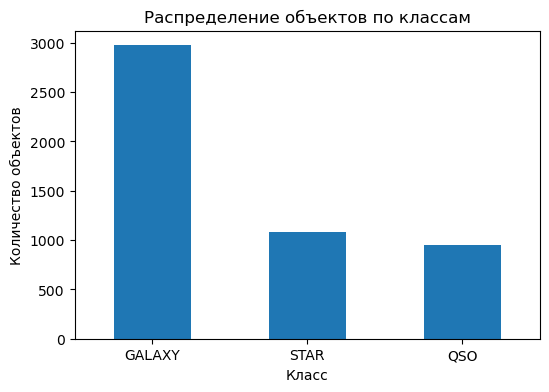

In [5]:
class_counts = df['class'].value_counts()

class_balance = pd.DataFrame({
    'objects_count': class_counts,
    'share_%': df['class'].value_counts(normalize=True).mul(100).round(2)
})

display(class_balance)

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar')
plt.title('Распределение объектов по классам')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.show()

В данных представлены три класса: `GALAXY`, `STAR`, `QSO`.  
Класс `GALAXY` имеет наибольшее количество объектов, поэтому выборка является несбалансированной.  
Следовательно, при оценке модели нужно учитывать не только общую долю правильных ответов, но и качество классификации по каждому классу отдельно.

3. Перед построением модели необходимо удалить признаки, которые являются техническими идентификаторами.  
Такие признаки могут не описывать физические свойства объекта, а только обозначать номер записи, наблюдения или оборудования.  
Их использование может ухудшить обобщающую способность модели.

In [6]:
features_to_drop = [
    'obj_ID',
    'run_ID',
    'rerun_ID',
    'cam_col',
    'field_ID',
    'spec_obj_ID',
    'plate',
    'MJD',
    'fiber_ID'
]

X = df.drop(columns=features_to_drop + ['class'])
y = df['class']

print('Удалённые признаки:')
print(features_to_drop)

print('\nОставшиеся признаки:')
display(X.head())

Удалённые признаки:
['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']

Оставшиеся признаки:


,alpha,delta,u,g,r,i,z,redshift
0,18.477096,0.398046,22.37395,20.90088,19.56963,18.81935,18.37379,0.000022
1,243.514415,28.709951,20.63683,20.46418,20.44647,20.23794,20.21350,1.584029
2,246.122674,35.108206,20.76552,20.74977,20.81548,20.50528,20.86766,1.889620
3,350.952384,-1.956800,21.97229,22.48574,20.73539,19.73239,19.19021,0.506479
4,211.061259,52.808307,26.17653,23.44365,21.82722,20.36805,19.63477,0.832708


Из набора данных удалены технические идентификаторы: `obj_ID`, `run_ID`, `rerun_ID`, `cam_col`, `field_ID`, `spec_obj_ID`, `plate`, `MJD`, `fiber_ID`.  
В модели оставлены признаки `alpha`, `delta`, `u`, `g`, `r`, `i`, `z`, `redshift`, так как они содержательно описывают наблюдаемый космический объект.  
Целевой признак `class` был отделён от входных признаков.

4. Целевой признак `class` извлекается в отдельную переменную `y`.  
Остальные признаки сохраняются в переменной `X` и далее используются как входные данные для модели.

In [8]:
print('Размерность X:', X.shape)
print('Размерность y:', y.shape)

print('\nПервые значения целевого признака:')
display(y.head())

Размерность X: (5000, 8)
Размерность y: (5000,)

Первые значения целевого признака:


0      STAR
1       QSO
2       QSO
3    GALAXY
4    GALAXY
Name: class, dtype: object

5. Набор данных разбивается на обучающую и тестовую выборки в соотношении 70/30.  
Параметр `random_state` установлен равным номеру варианта — 2.  
Дополнительно используется стратификация, чтобы сохранить примерно одинаковое распределение классов в обучающей и тестовой выборках.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Размер обучающей выборки:', X_train.shape)
print('Размер тестовой выборки:', X_test.shape)

print('\nДоли классов в обучающей выборке:')
display(y_train.value_counts(normalize=True).mul(100).round(2).to_frame('share_%'))

print('\nДоли классов в тестовой выборке:')
display(y_test.value_counts(normalize=True).mul(100).round(2).to_frame('share_%'))

Размер обучающей выборки: (3500, 8)
Размер тестовой выборки: (1500, 8)

Доли классов в обучающей выборке:


,share_%
class,
GALAXY,59.43
STAR,21.63
QSO,18.94



Доли классов в тестовой выборке:


,share_%
class,
GALAXY,59.47
STAR,21.60
QSO,18.93


Разбиение выполнено в соотношении 70/30.  
Стратификация позволяет сохранить баланс классов в обучающей и тестовой выборках близким к исходному распределению.  
Это особенно важно, так как классы в исходных данных распределены неравномерно.

6. Подготовка признаков к обучению модели

Для входных признаков применяется масштабирование `StandardScaler`.  
Этот метод приводит признаки к нулевому среднему и единичному стандартному отклонению.

Такое масштабирование выбрано потому, что `SGDClassifier` является линейной моделью, обучаемой градиентным методом.  
Если признаки имеют разные масштабы, модель может обучаться нестабильно или медленнее.

Целевой признак `class` является категориальным, поэтому его необходимо преобразовать в числовой формат.  
Для этого используется `LabelEncoder`.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

encoder = LabelEncoder()

y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

print('Кодировка классов:')
for code_value, class_name in enumerate(encoder.classes_):
    print(f'{class_name} -> {code_value}')

display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

Кодировка классов:
GALAXY -> 0
QSO -> 1
STAR -> 2


,alpha,delta,u,g,r,i,z,redshift
0,0.573711,1.300916,-0.204565,0.280142,0.774246,1.112760,0.964853,2.084231
1,-1.286135,-1.166455,0.948780,0.254485,-0.001463,-0.122382,-0.189976,-0.780293
2,1.837750,0.201467,0.564726,0.750782,0.545166,0.410955,0.405429,-0.180602
3,0.463686,1.346711,-1.436258,-1.480100,-1.400064,-1.354620,-1.322540,-0.779833
4,1.606576,-0.341570,0.121867,0.784324,0.736816,0.387095,0.262505,0.030466


Масштабизатор обучается только на обучающей выборке с помощью `fit_transform`.  
К тестовой выборке применяется только `transform`, чтобы не допустить утечки информации из тестовых данных.  
Целевой признак закодирован числовыми метками, так как модель не работает напрямую со строковыми названиями классов.

7. Создание и обучение базовой модели SGDClassifier

Создаётся модель `SGDClassifier`.  
Параметр `random_state` установлен равным номеру варианта — 2.  
Остальные параметры оставлены со значениями по умолчанию.

In [12]:
base_model = SGDClassifier(random_state=RANDOM_STATE)

base_model.fit(X_train_scaled, y_train_enc)

base_model

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


8. Оценка качества базовой модели

Качество модели оценивается отдельно на обучающей и тестовой выборках.  
Для анализа используются матрица ошибок и отчёт `classification_report`, который содержит значения precision, recall и F1-score.

In [13]:
y_train_pred_base = base_model.predict(X_train_scaled)
y_test_pred_base = base_model.predict(X_test_scaled)

cm_train_base = confusion_matrix(y_train_enc, y_train_pred_base)
cm_test_base = confusion_matrix(y_test_enc, y_test_pred_base)

print('Матрица ошибок на обучающей выборке:')
display(pd.DataFrame(cm_train_base, index=encoder.classes_, columns=encoder.classes_))

print('Матрица ошибок на тестовой выборке:')
display(pd.DataFrame(cm_test_base, index=encoder.classes_, columns=encoder.classes_))

print('Classification report: обучающая выборка')
print(classification_report(y_train_enc, y_train_pred_base, target_names=encoder.classes_))

print('Classification report: тестовая выборка')
print(classification_report(y_test_enc, y_test_pred_base, target_names=encoder.classes_))

base_test_macro_f1 = f1_score(y_test_enc, y_test_pred_base, average='macro')
base_test_weighted_f1 = f1_score(y_test_enc, y_test_pred_base, average='weighted')

print('Базовая модель, macro-F1 на тесте:', round(base_test_macro_f1, 4))
print('Базовая модель, weighted-F1 на тесте:', round(base_test_weighted_f1, 4))

Матрица ошибок на обучающей выборке:


,GALAXY,QSO,STAR
GALAXY,1908,118,54
QSO,53,610,0
STAR,126,0,631


Матрица ошибок на тестовой выборке:


,GALAXY,QSO,STAR
GALAXY,812,61,19
QSO,20,263,1
STAR,52,0,272


Classification report: обучающая выборка
              precision    recall  f1-score   support

      GALAXY       0.91      0.92      0.92      2080
         QSO       0.84      0.92      0.88       663
        STAR       0.92      0.83      0.88       757

    accuracy                           0.90      3500
   macro avg       0.89      0.89      0.89      3500
weighted avg       0.90      0.90      0.90      3500

Classification report: тестовая выборка
              precision    recall  f1-score   support

      GALAXY       0.92      0.91      0.91       892
         QSO       0.81      0.93      0.87       284
        STAR       0.93      0.84      0.88       324

    accuracy                           0.90      1500
   macro avg       0.89      0.89      0.89      1500
weighted avg       0.90      0.90      0.90      1500

Базовая модель, macro-F1 на тесте: 0.8876
Базовая модель, weighted-F1 на тесте: 0.8983


Матрица ошибок показывает, какие классы модель определяет правильно, а какие путает между собой.  
Так как выборка несбалансирована, основной акцент делается не только на `accuracy`, но и на `macro-F1`.  
Метрика `macro-F1` усредняет качество по всем классам без учёта их размера, поэтому она лучше отражает качество модели при неравномерном распределении классов.

Если значения метрик на тестовой выборке близки к значениям на обучающей выборке, то сильного переобучения не наблюдается.  
Если качество на обучающей выборке заметно выше, чем на тестовой, это может говорить о переобучении.

### Вывод по заданию 1

В ходе выполнения первого задания был загружен и изучен набор данных SDSS.  
Было установлено, что пропущенные значения отсутствуют, а целевой признак содержит три класса: `GALAXY`, `STAR`, `QSO`.  
Распределение классов является несбалансированным, поэтому при оценке качества модели важно учитывать метрики по каждому классу.

Из набора были удалены технические идентификаторы, которые не являются содержательными признаками для классификации.  
После этого входные признаки были масштабированы с помощью `StandardScaler`, а целевой признак был закодирован с помощью `LabelEncoder`.

Базовая модель `SGDClassifier` построена и оценена на обучающей и тестовой выборках.  
Полученные результаты далее используются как базовый уровень качества для сравнения с моделями после подбора гиперпараметров.

## Задание 2

1. Создание модели и вывод доступных параметров

В этом пункте создаётся объект `SGDClassifier`, после чего выводится список всех доступных параметров модели.  
Это позволяет понять, какие гиперпараметры можно настраивать при дальнейшем подборе.

In [14]:
sgd_for_search = SGDClassifier(random_state=RANDOM_STATE)

params = sgd_for_search.get_params()

print('Количество доступных параметров:', len(params))

display(pd.DataFrame(params.items(), columns=['parameter', 'default_value']))

Количество доступных параметров: 21


,parameter,default_value
0,alpha,0.0001
1,average,False
2,class_weight,None
3,early_stopping,False
4,epsilon,0.1
5,eta0,0.0
6,fit_intercept,True
7,l1_ratio,0.15
8,learning_rate,optimal
9,loss,hinge


Полная сетка параметров содержит много комбинаций.  
Чтобы перебор выполнялся быстрее и стабильнее в учебной среде, для этапа поиска гиперпараметров используется стратифицированная часть обучающей выборки.  
При этом финальная оценка лучших моделей выполняется на исходной тестовой выборке.

In [16]:
X_search_scaled, _, y_search_enc, _ = train_test_split(
    X_train_scaled,
    y_train_enc,
    train_size=1000,
    random_state=RANDOM_STATE,
    stratify=y_train_enc
)

print('Размер обучающей подвыборки для подбора гиперпараметров:', X_search_scaled.shape)

Размер обучающей подвыборки для подбора гиперпараметров: (1000, 8)


2. Создание сетки параметров

Сетка параметров включает:

- 4 функции потерь;
- 2 типа регуляризатора;
- 10 значений коэффициента регуляризации `alpha` от 10^-6 до 10;
- значения `n_iter_no_change` от 5 до 10 с шагом 1.

Таким образом, сетка соответствует требованиям задания.

In [17]:
param_grid = {
    'loss': ['hinge', 'log_loss', 'modified_huber', 'squared_hinge'],
    'penalty': ['l1', 'l2'],
    'alpha': np.logspace(-6, 1, 10),
    'n_iter_no_change': list(range(5, 11))
}

combinations_count = (
    len(param_grid['loss']) *
    len(param_grid['penalty']) *
    len(param_grid['alpha']) *
    len(param_grid['n_iter_no_change'])
)

print('Количество комбинаций в сетке:', combinations_count)

param_grid

Количество комбинаций в сетке: 480


{'loss': ['hinge', 'log_loss', 'modified_huber', 'squared_hinge'],
 'penalty': ['l1', 'l2'],
 'alpha': array([1.00000000e-06, 5.99484250e-06, 3.59381366e-05, 2.15443469e-04,
        1.29154967e-03, 7.74263683e-03, 4.64158883e-02, 2.78255940e-01,
        1.66810054e+00, 1.00000000e+01]),
 'n_iter_no_change': [5, 6, 7, 8, 9, 10]}

3. Обоснование выбора метрики качества

Для подбора оптимальных гиперпараметров используется метрика `f1_macro`.

Выбор этой метрики обусловлен тем, что в задаче имеется три класса, распределённые неравномерно.  
Если использовать только `accuracy`, модель может показывать высокий результат за счёт правильного распознавания самого многочисленного класса.  
Метрика `f1_macro` рассчитывает F1-score отдельно по каждому классу, а затем усредняет значения без учёта размера классов.

Поэтому `f1_macro` лучше подходит для данной задачи, так как позволяет равноправно учитывать качество классификации для `GALAXY`, `STAR` и `QSO`.

4. Подбор гиперпараметров с помощью GridSearchCV

`GridSearchCV` выполняет полный перебор всех комбинаций из заданной сетки параметров.  
Для каждой комбинации проводится кросс-валидация, после чего выбирается набор параметров с лучшим значением выбранной метрики `f1_macro`.

Для контроля вычислительных затрат дополнительно измеряется время выполнения перебора.

In [18]:
grid_model = SGDClassifier(
    random_state=RANDOM_STATE,
    max_iter=10,
    tol=1e-2
)

grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=2,
    n_jobs=1,
    return_train_score=True
)

start_time = time.perf_counter()

grid_search.fit(X_search_scaled, y_search_enc)

grid_time = time.perf_counter() - start_time

print(f'Время GridSearchCV: {grid_time:.2f} секунд')

Время GridSearchCV: 17.00 секунд


5. Результаты GridSearchCV по наборам параметров

После выполнения полного перебора выведем:

- первые пять проверенных наборов параметров;
- последние пять проверенных наборов параметров;
- пять лучших наборов параметров по метрике `f1_macro`.

In [19]:
grid_results = pd.DataFrame(grid_search.cv_results_)

show_columns = [
    'params',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'rank_test_score'
]

print('Первые пять наборов параметров:')
display(grid_results[show_columns].head(5))

print('Последние пять наборов параметров:')
display(grid_results[show_columns].tail(5))

print('Пять лучших наборов параметров:')
display(grid_results.sort_values('rank_test_score')[show_columns].head(5))

Первые пять наборов параметров:


,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,"{'alpha': 1e-06, 'loss': 'hinge', 'n_iter_no_c...",0.759420,0.009161,0.770234,306
1,"{'alpha': 1e-06, 'loss': 'hinge', 'n_iter_no_c...",0.825956,0.017681,0.834085,196
2,"{'alpha': 1e-06, 'loss': 'hinge', 'n_iter_no_c...",0.782753,0.014173,0.795430,285
3,"{'alpha': 1e-06, 'loss': 'hinge', 'n_iter_no_c...",0.825956,0.017681,0.834085,196
4,"{'alpha': 1e-06, 'loss': 'hinge', 'n_iter_no_c...",0.782753,0.014173,0.795430,285


Последние пять наборов параметров:


,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
475,"{'alpha': 10.0, 'loss': 'squared_hinge', 'n_it...",0.316641,0.053839,0.324508,385
476,"{'alpha': 10.0, 'loss': 'squared_hinge', 'n_it...",0.248432,0.000000,0.248432,409
477,"{'alpha': 10.0, 'loss': 'squared_hinge', 'n_it...",0.316641,0.053839,0.324508,385
478,"{'alpha': 10.0, 'loss': 'squared_hinge', 'n_it...",0.248432,0.000000,0.248432,409
479,"{'alpha': 10.0, 'loss': 'squared_hinge', 'n_it...",0.316641,0.053839,0.324508,385


Пять лучших наборов параметров:


,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
264,"{'alpha': 0.007742636826811269, 'loss': 'modif...",0.931385,0.00427,0.930601,1
268,"{'alpha': 0.007742636826811269, 'loss': 'modif...",0.931385,0.00427,0.930601,1
270,"{'alpha': 0.007742636826811269, 'loss': 'modif...",0.931385,0.00427,0.930601,1
272,"{'alpha': 0.007742636826811269, 'loss': 'modif...",0.931385,0.00427,0.930601,1
274,"{'alpha': 0.007742636826811269, 'loss': 'modif...",0.931385,0.00427,0.930601,1


6. Лучший классификатор GridSearchCV

Выведем лучший классификатор, лучший набор гиперпараметров и значение лучшей оценки по метрике `f1_macro`.

In [20]:
print('Лучший классификатор:')
print(grid_search.best_estimator_)

print('\nЛучшие параметры:')
print(grid_search.best_params_)

print('\nЛучшая оценка f1_macro на кросс-валидации:')
print(round(grid_search.best_score_, 4))

Лучший классификатор:
SGDClassifier(alpha=np.float64(0.007742636826811269), loss='modified_huber',
              max_iter=10, penalty='l1', random_state=2, tol=0.01)

Лучшие параметры:
{'alpha': np.float64(0.007742636826811269), 'loss': 'modified_huber', 'n_iter_no_change': 5, 'penalty': 'l1'}

Лучшая оценка f1_macro на кросс-валидации:
0.9314


7. Оценка лучшей модели GridSearchCV на тестовой выборке

Лучшая модель, найденная с помощью `GridSearchCV`, проверяется на тестовой выборке.  
Выводятся матрица ошибок, основные метрики качества и сравнение с базовой моделью из задания 1.

In [21]:
best_grid_model = grid_search.best_estimator_

y_test_pred_grid = best_grid_model.predict(X_test_scaled)

cm_test_grid = confusion_matrix(y_test_enc, y_test_pred_grid)

print('Матрица ошибок GridSearchCV на тестовой выборке:')
display(pd.DataFrame(cm_test_grid, index=encoder.classes_, columns=encoder.classes_))

print('Classification report: GridSearchCV, тестовая выборка')
print(classification_report(y_test_enc, y_test_pred_grid, target_names=encoder.classes_))

grid_test_macro_f1 = f1_score(y_test_enc, y_test_pred_grid, average='macro')
grid_test_weighted_f1 = f1_score(y_test_enc, y_test_pred_grid, average='weighted')

comparison_grid = pd.DataFrame({
    'model': ['Base SGDClassifier', 'GridSearchCV best'],
    'test_macro_f1': [base_test_macro_f1, grid_test_macro_f1],
    'test_weighted_f1': [base_test_weighted_f1, grid_test_weighted_f1]
})

display(comparison_grid.round(4))

Матрица ошибок GridSearchCV на тестовой выборке:


,GALAXY,QSO,STAR
GALAXY,857,24,11
QSO,37,247,0
STAR,44,3,277


Classification report: GridSearchCV, тестовая выборка
              precision    recall  f1-score   support

      GALAXY       0.91      0.96      0.94       892
         QSO       0.90      0.87      0.89       284
        STAR       0.96      0.85      0.91       324

    accuracy                           0.92      1500
   macro avg       0.93      0.90      0.91      1500
weighted avg       0.92      0.92      0.92      1500



,model,test_macro_f1,test_weighted_f1
0,Base SGDClassifier,0.8876,0.8983
1,GridSearchCV best,0.9090,0.9201


Если значение `macro-F1` после подбора гиперпараметров увеличилось, значит модель стала лучше работать в среднем по всем классам.  
Если прирост небольшой, это означает, что базовые параметры уже были достаточно близки к подходящим для данного набора данных.  
Также важно учитывать матрицу ошибок: она показывает, какие классы модель продолжает путать между собой.

### Выводы по GridSearchCV

`GridSearchCV` выполняет полный перебор всех комбинаций параметров из заданной сетки.  
Главное преимущество этого метода — контролируемость и полнота поиска.  
Если оптимальная комбинация находится внутри заданной сетки, полный перебор позволяет её найти.

Недостаток метода заключается в высокой вычислительной стоимости.  
При увеличении количества параметров или числа значений для каждого параметра время перебора быстро возрастает.  
Поэтому `GridSearchCV` рационально использовать тогда, когда сетка параметров не слишком большая.

9. Подбор гиперпараметров с помощью RandomizedSearchCV

`RandomizedSearchCV` выполняет не полный перебор всех комбинаций, а случайно выбирает ограниченное количество наборов параметров.  
Такой подход позволяет сократить время подбора, особенно если сетка параметров большая.

Для сопоставления с `GridSearchCV` используется та же сетка параметров и та же метрика качества `f1_macro`.

In [24]:
random_model = SGDClassifier(
    random_state=RANDOM_STATE,
    max_iter=10,
    tol=1e-2
)

random_search = RandomizedSearchCV(
    estimator=random_model,
    param_distributions=param_grid,
    n_iter=60,
    scoring='f1_macro',
    cv=2,
    n_jobs=1,
    random_state=RANDOM_STATE,
    return_train_score=True
)

start_time = time.perf_counter()

random_search.fit(X_search_scaled, y_search_enc)

random_time = time.perf_counter() - start_time

print(f'Время RandomizedSearchCV: {random_time:.2f} секунд')

Время RandomizedSearchCV: 2.17 секунд


10. Результаты RandomizedSearchCV

После случайного перебора выведем:

- первые пять проверенных наборов параметров;
- последние пять проверенных наборов параметров;
- пять лучших наборов параметров;
- лучший классификатор;
- лучшие параметры;
- лучшую оценку по метрике `f1_macro`.

In [25]:
random_results = pd.DataFrame(random_search.cv_results_)

print('Первые пять наборов параметров:')
display(random_results[show_columns].head(5))

print('Последние пять наборов параметров:')
display(random_results[show_columns].tail(5))

print('Пять лучших наборов параметров:')
display(random_results.sort_values('rank_test_score')[show_columns].head(5))

print('Лучший классификатор RandomizedSearchCV:')
print(random_search.best_estimator_)

print('\nЛучшие параметры RandomizedSearchCV:')
print(random_search.best_params_)

print('\nЛучшая оценка f1_macro на кросс-валидации:')
print(round(random_search.best_score_, 4))

Первые пять наборов параметров:


,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,"{'penalty': 'l1', 'n_iter_no_change': 10, 'los...",0.248432,0.000000,0.248432,55
1,"{'penalty': 'l2', 'n_iter_no_change': 5, 'loss...",0.673561,0.031352,0.664524,45
2,"{'penalty': 'l2', 'n_iter_no_change': 9, 'loss...",0.751550,0.053184,0.757374,40
3,"{'penalty': 'l2', 'n_iter_no_change': 8, 'loss...",0.788997,0.007023,0.801807,35
4,"{'penalty': 'l2', 'n_iter_no_change': 7, 'loss...",0.470054,0.048734,0.481199,51


Последние пять наборов параметров:


,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
55,"{'penalty': 'l2', 'n_iter_no_change': 10, 'los...",0.824888,0.022284,0.822174,28
56,"{'penalty': 'l1', 'n_iter_no_change': 10, 'los...",0.810484,0.064166,0.824002,31
57,"{'penalty': 'l1', 'n_iter_no_change': 10, 'los...",0.248432,0.000000,0.248432,55
58,"{'penalty': 'l1', 'n_iter_no_change': 5, 'loss...",0.769421,0.050367,0.785867,37
59,"{'penalty': 'l1', 'n_iter_no_change': 10, 'los...",0.885267,0.008377,0.891964,10


Пять лучших наборов параметров:


,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
41,"{'penalty': 'l1', 'n_iter_no_change': 5, 'loss...",0.931385,0.004270,0.930601,1
39,"{'penalty': 'l1', 'n_iter_no_change': 7, 'loss...",0.931385,0.004270,0.930601,1
53,"{'penalty': 'l1', 'n_iter_no_change': 5, 'loss...",0.930869,0.005523,0.926402,3
20,"{'penalty': 'l1', 'n_iter_no_change': 8, 'loss...",0.930869,0.005523,0.926402,3
43,"{'penalty': 'l1', 'n_iter_no_change': 7, 'loss...",0.912905,0.030177,0.912671,5


Лучший классификатор RandomizedSearchCV:
SGDClassifier(alpha=np.float64(0.007742636826811269), loss='modified_huber',
              max_iter=10, n_iter_no_change=7, penalty='l1', random_state=2,
              tol=0.01)

Лучшие параметры RandomizedSearchCV:
{'penalty': 'l1', 'n_iter_no_change': 7, 'loss': 'modified_huber', 'alpha': np.float64(0.007742636826811269)}

Лучшая оценка f1_macro на кросс-валидации:
0.9314


Лучшая модель, найденная случайным поиском, оценивается на тестовой выборке.  
Далее результаты сравниваются с базовой моделью и моделью, найденной через `GridSearchCV`.

In [27]:
best_random_model = random_search.best_estimator_

y_test_pred_random = best_random_model.predict(X_test_scaled)

cm_test_random = confusion_matrix(y_test_enc, y_test_pred_random)

print('Матрица ошибок RandomizedSearchCV на тестовой выборке:')
display(pd.DataFrame(cm_test_random, index=encoder.classes_, columns=encoder.classes_))

print('Classification report: RandomizedSearchCV, тестовая выборка')
print(classification_report(y_test_enc, y_test_pred_random, target_names=encoder.classes_))

random_test_macro_f1 = f1_score(y_test_enc, y_test_pred_random, average='macro')
random_test_weighted_f1 = f1_score(y_test_enc, y_test_pred_random, average='weighted')

final_comparison = pd.DataFrame({
    'model': [
        'Base SGDClassifier',
        'GridSearchCV best',
        'RandomizedSearchCV best'
    ],
    'test_macro_f1': [
        base_test_macro_f1,
        grid_test_macro_f1,
        random_test_macro_f1
    ],
    'test_weighted_f1': [
        base_test_weighted_f1,
        grid_test_weighted_f1,
        random_test_weighted_f1
    ],
    'search_time_sec': [
        np.nan,
        grid_time,
        random_time
    ]
})

display(final_comparison.round(4))

Матрица ошибок RandomizedSearchCV на тестовой выборке:


,GALAXY,QSO,STAR
GALAXY,858,24,10
QSO,37,247,0
STAR,53,3,268


Classification report: RandomizedSearchCV, тестовая выборка
              precision    recall  f1-score   support

      GALAXY       0.91      0.96      0.93       892
         QSO       0.90      0.87      0.89       284
        STAR       0.96      0.83      0.89       324

    accuracy                           0.92      1500
   macro avg       0.92      0.89      0.90      1500
weighted avg       0.92      0.92      0.91      1500



,model,test_macro_f1,test_weighted_f1,search_time_sec
0,Base SGDClassifier,0.8876,0.8983,NaN
1,GridSearchCV best,0.9090,0.9201,17.0047
2,RandomizedSearchCV best,0.9028,0.9145,2.1662


**Сопоставление результатов.**

`RandomizedSearchCV` обычно работает быстрее, потому что проверяет не все возможные комбинации параметров, а только случайно выбранную часть.  
При этом качество может быть близким к результату полного перебора, если случайный поиск попал в удачные области пространства параметров.

Если качество `RandomizedSearchCV` оказалось близким к `GridSearchCV`, то случайный поиск можно считать более рациональным по соотношению времени и результата.  
Если же качество заметно ниже, значит количества случайных итераций было недостаточно или удачные параметры не попали в выбранные комбинации.

11. Итоговые выводы

В работе была построена базовая модель `SGDClassifier`, а затем выполнен подбор гиперпараметров двумя способами: `GridSearchCV` и `RandomizedSearchCV`.

Для оценки качества использовалась метрика `f1_macro`, так как классы в наборе данных распределены неравномерно.  
Эта метрика позволяет оценивать качество классификации по всем классам равноправно, не отдавая преимущество самому многочисленному классу.

`GridSearchCV` целесообразно использовать, когда сетка параметров небольшая и есть возможность проверить все комбинации.  
Преимущество этого метода — полный и контролируемый перебор.  
Недостаток — большие временные затраты при увеличении количества параметров.

`RandomizedSearchCV` рациональнее применять при большой сетке параметров.  
Он позволяет быстрее получить приемлемый результат, проверяя только часть возможных комбинаций.  
Практическая рекомендация: сначала использовать `RandomizedSearchCV` для быстрого поиска перспективной области параметров, а затем при необходимости уточнить результат с помощью `GridSearchCV` на более узкой сетке.